In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Open the spreadsheet

In [2]:
# 1. Define the file path and sheet name
file_path = 'graph_ingredients.xlsx'
sheet = 'Edge List_Expanded'

# 2. Load data into a DataFrame

In [3]:
# 2. Read the Excel file into a DataFrame
df = pd.read_excel(file_path, sheet_name=sheet)

# 3. View the first few rows to confirm it worked
print(df.head())

df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce').fillna(0)

    Source                 Target  Weight  \
0     Root                Younger     0.4   
1     Root               Same age     0.4   
2     Root                  Older     0.2   
3  Younger  Younger (child's gen)     0.5   
4  Younger     Younger (same gen)     0.5   

                                             Note  \
0  Branch probability = 0.4 (Estimated frequency)   
1  Branch probability = 0.4 (Estimated frequency)   
2  Branch probability = 0.2 (Estimated frequency)   
3         Branch probability = 0.5 (Evenly split)   
4         Branch probability = 0.5 (Evenly split)   

                          Cumulative Logic  
0                   1.0 (Root) * 0.4 = 0.4  
1                   1.0 (Root) * 0.4 = 0.4  
2                   1.0 (Root) * 0.2 = 0.2  
3  0.4 (Incoming from Younger) * 0.5 = 0.2  
4  0.4 (Incoming from Younger) * 0.5 = 0.2  


# 3. Create the Graph

In [4]:
# 3. Create the Graph
G = nx.from_pandas_edgelist(df, source='Source', target='Target', edge_attr='Weight')

# 4. Visualize

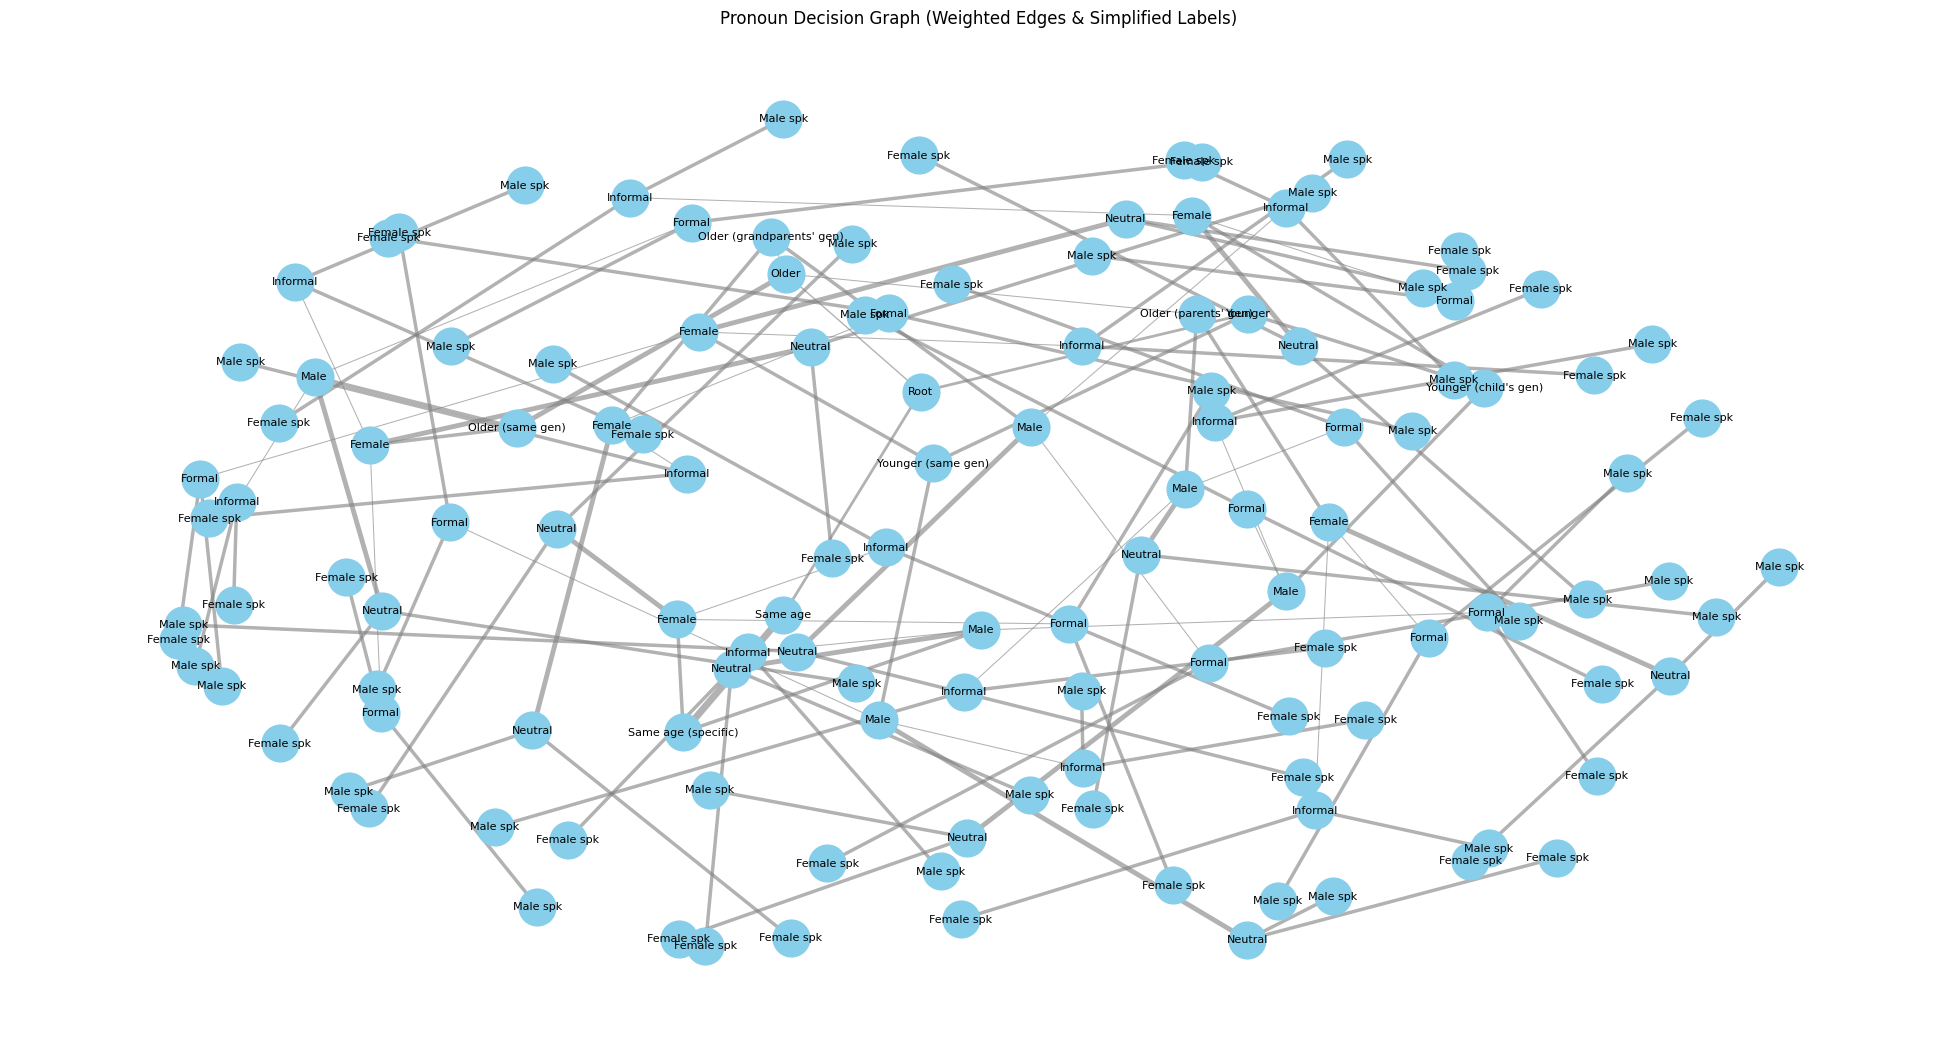

In [5]:
plt.figure(figsize=(25, 13)) # Increased height slightly for better spacing
pos = nx.spring_layout(G, k=0.5) # Layout for nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')

# Draw edges with thickness based on Weight
weights = [G[u][v]['Weight'] * 5 for u, v in G.edges()] # Scaling weight for visibility
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)

# --- MODIFICATION: Create simplified labels ---
# This splits the string by " - " and takes the very last element
# Example: "Younger - Male - Neutral" becomes just "Neutral"
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels using the new 'labels' parameter
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Pronoun Decision Graph (Weighted Edges & Simplified Labels)")
plt.axis('off')
plt.show()

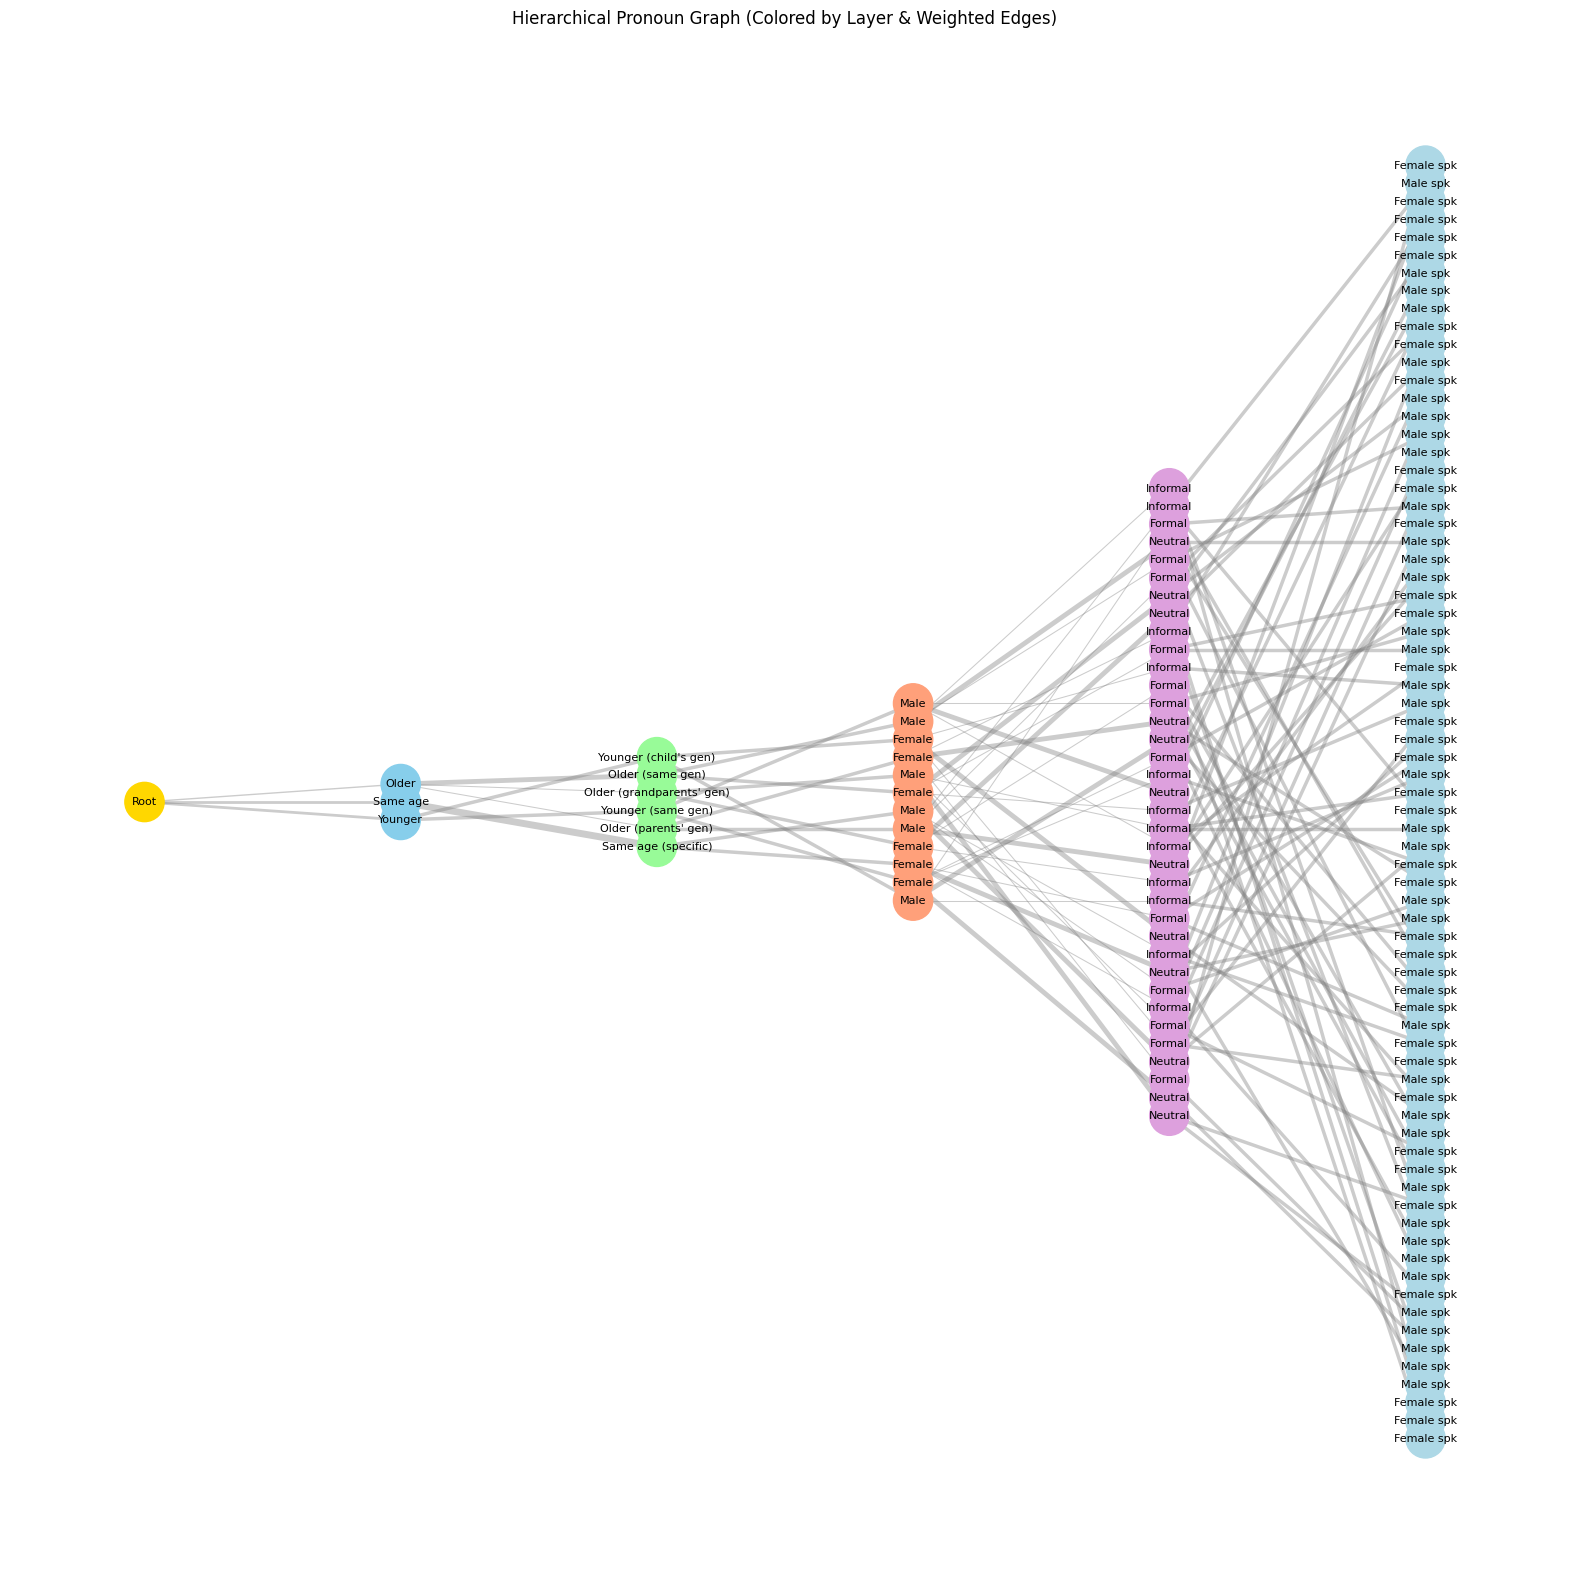

In [6]:
# 1. Calculate depth from Root to determine layers (if not already done)
depths = nx.single_source_shortest_path_length(G, 'Root')
for node, depth in depths.items():
    G.nodes[node]['layer'] = depth

# 2. Define your color palette for each layer
# Layer 0: Root, Layer 1: Age, Layer 2: Gender, Layer 3: Social, Layer 4: Speaker
layer_colors = {
    0: '#FFD700', # Gold
    1: '#87CEEB', # Sky Blue
    2: '#98FB98', # Pale Green
    3: '#FFA07A', # Light Salmon
    4: '#DDA0DD', # Plum
    5: '#ADD8E6'  # Light Blue - Added for layer 5
}

# 3. Create a list of colors for each node in the order they appear in G.nodes()
node_colors = [layer_colors[G.nodes[n]['layer']] for n in G.nodes()]

# 4. Visualize
plt.figure(figsize=(20, 20))
# Use multipartite_layout for the hierarchical look
pos = nx.multipartite_layout(G, subset_key='layer')

# Draw nodes with the new node_colors list
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors)

# Draw edges with thickness based on Weight
weights = [G.get_edge_data(u, v, default={}).get('Weight', 0) * 5 for u, v in G.edges()] # Added .get('Weight', 0) to handle missing 'Weight' attribute
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

# Create simplified labels
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Hierarchical Pronoun Graph (Colored by Layer & Weighted Edges)")
plt.axis('off')
plt.show()

## **WE CAN MODIFY THE WEIGHTS or YOU GUYS CAN ADD YOUR FEEDBACKS/IDEAS HERE**

* Age: Most of people in the target group know how to address pronouns to the older, but face difficulties with youngers and same age.
  * Root - Younger: 0.4
  * Root - Same age: 0.4
  * Root - Older: 0.2
* Age (specific):
  * Younger group:
    * younger - Younger (child's gen): 0.5
    * Younger - Younger (same gen): 0.5
  * Same age group
    * Same age- Same age: 1
  * Older group: Target group mostly talks vietnamese to people who are around parents' or grandparents' gen
    * Older - Older (same gen): 0.7
    * Older - Older (parents' gen): 0.15
    * Older - Older (grandparents' gen): 0.15
* Gender:
  * ~ - Male: 0.5
  * ~ - Female: 0.5
* Social: The game is now designed for social situations. In my opinion, the case neutral can be the most frequent that learners can face, when they talk to others in real life. But we can modify the weight for this layer. At the moment, I set it as:
  * ~ - Informal: 0.15
  * ~ - Neutral: 0.7
  * ~ - Formal: 0.15
* Speaker gender:
  * ~ - Male: 0.5
  * ~ - Female: 0.5

# 5. Weights → Edges for similarity
Similarity here indicates more frequent scenerios

In [7]:
# import itertools

# # 1. Identify nodes (layer 5)
# """Extracts Nodes: It finds all the end scenarios (nodes at layer 5)."""

# leaf_nodes = [n for n, attr in G.nodes(data=True) if attr.get('layer') == 5]


# # 2. Extract features for each node by tracing the shortest path from Root
# """Extracts Features:
#     It traces the path back to the root for each node to figure out its specific attributes
#     (Age, Age specific, Gender, Social, Speaker Gender)."""

# leaf_features = {}
# for leaf in leaf_nodes:
#     path = nx.shortest_path(G, source='Root', target=leaf)
#     # The path contains nodes at each layer:
#     # [Root, Age, Age(specific), Gender, Social, Speaker Gender]
#     age = path[1]
#     age_spec = path[2]
#     # Extract just the specific attribute name from the long node label
#     gender = path[3].split(' - ')[-1]
#     social = path[4].split(' - ')[-1]
#     spk_gender = path[5].split(' - ')[-1]

#     leaf_features[leaf] = [age, age_spec, gender, social, spk_gender]


# # 3. Define the weights for each feature value based on our requirements
# weight_dict = {
#     'Younger': 0.4, 'Same age': 0.4, 'Older': 0.2,
#     "Younger (child's gen)": 0.5, 'Younger (same gen)': 0.5,
#     'Same age (specific)': 1.0,  # Updated to match the restored label
#     'Older (same gen)': 0.7, "Older (parents' gen)": 0.15, "Older (grandparents' gen)": 0.15,
#     'Male': 0.5, 'Female': 0.5,
#     'Informal': 0.15, 'Neutral': 0.7, 'Formal': 0.15,
#     'Male spk': 0.5, 'Female spk': 0.5
# }


# # 4. Calculate similarity scores between all pairs of nodes
# """Calculates Similarity:
#     It compares every pair of nodes.
#     If they share an attribute, it adds the weight of that attribute to their similarity score."""

# similarity_edges = []
# for u, v in itertools.combinations(leaf_nodes, 2):
#     feat_u = leaf_features[u]
#     feat_v = leaf_features[v]

#     sim_score = 0
#     for f1, f2 in zip(feat_u, feat_v):
#         if f1 == f2:
#             # Add the weight if they share the same feature. Default to 0.1 if not found just in case.
#             sim_score += weight_dict.get(f1, 0.1)

#     # Only add an edge if the similarity is reasonably high
#     # The max possible score is 0.4 + 1.0 + 0.5 + 0.7 + 0.5 = 3.1 (Eg: Same age - Same age - Female - Neutral - Female Spk)
#     if sim_score >= 1.8:
#       # set it to 1.8 to avoid a completely cluttered graph, but we can adjust this
#         similarity_edges.append((u, v, sim_score))


In [8]:
# # 5. Create and Visualize the Similarity Graph
# """Visualizes:
#     It plots a new graph where edges only exist if the similarity score is above a certain threshold
#     (At the moment, set it to 1.8 to avoid a completely cluttered graph, but we can adjust this).
#     Thicker edges mean higher similarity."""

# S = nx.Graph()
# for u, v, w in similarity_edges:
#     S.add_edge(u, v, weight=w)

# # Adjusted 'k' for better spacing between clusters, and increased iterations for stability
# pos_s = nx.spring_layout(S, k=0.3, iterations=50, seed=42)

# # Calculate node degree to use for coloring (more connected = hotter color)
# degrees = dict(S.degree())
# node_colors = [degrees[n] for n in S.nodes()]

# # Define edge_weights based on the similarity scores
# edge_weights = [S[u][v]['weight'] ** 2 for u, v in S.edges()]

# # 5 = Shows the full path (e.g., "Younger (child's gen) - Male - Informal - Female spk")
# parts_to_show = 5

# # Create the custom labels based on your choice above
# custom_labels = {n: " - ".join(str(n).split(' - ')[-parts_to_show:]) for n in S.nodes()}

# # --- Drawing the Graph ---
# plt.figure(figsize=(25, 25))

# # Re-draw Nodes
# nodes = nx.draw_networkx_nodes(S, pos_s, node_size=500, node_color=node_colors,
#                                cmap=plt.cm.coolwarm, edgecolors='white', linewidths=1.5)

# # Re-draw Edges
# nx.draw_networkx_edges(S, pos_s, width=edge_weights, alpha=0.15, edge_color='#555555')

# # Draw the Custom Labels
# nx.draw_networkx_labels(S, pos_s, labels=custom_labels, font_size=8, font_family='sans-serif',
#                         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

# plt.title(f"Node Similarity Graph", fontsize=16)
# plt.axis('off')
# plt.colorbar(nodes, label="Number of Similar Scenarios (Degree)", shrink=0.5, aspect=20)
# plt.show()

# Based on everything above, save graph + export graph

In [9]:
import pandas as pd
import networkx as nx
import uuid
import json
from networkx.readwrite import json_graph

G_schema = nx.DiGraph() 
db_df = pd.read_excel("db_pronouns_social-adressing_v1.xlsx", sheet_name="input_nodes")
db_df = db_df[~db_df['adressing relation'].str.contains("child", na=False)] 

# 🌟 CLEANUP 1: Automatically fix "urdu" vs "Urdu" typos!
db_df['language'] = db_df['language'].fillna('Unknown').astype(str).str.strip().str.title()

def map_game_nodes(row):
    relation = str(row['adressing relation']).lower()
    note = str(row['any note?']).lower()
    
    # 🌟 CLEANUP 2: Check "Senior" BEFORE "Middle-aged" so "grandparents" doesn't trigger "parents"
    if "younger" in relation: age = "Younger"
    elif "senior" in relation or "grandparent" in relation: age = "Senior (grandparents' gen)"
    elif "middle-age" in relation or "parents" in relation: age = "Middle-aged (parents' gen)"
    elif "older" in relation: age = "Older (same gen)"
    else: age = "Same Age"
        
    # 🌟 CLEANUP 3: Bulletproof Gender checking
    addr_options = ["Male", "Female"]
    if "you as male" in note or "bhai" in note or "uncle" in relation or "uncle" in note or ("male" in note and "female" not in note): 
        addr_options = ["Male"]
    elif "you as female" in note or "baji" in note or "apa" in note or "aunt" in relation or "aunty" in note or "khala" in note or ("female" in note): 
        addr_options = ["Female"]

    social_options = ["Neutral"]
    if "casual" in note or "informal" in note: 
        social_options = ["Informal"]
    elif "formal" in note or "polite" in note or "respect" in note: 
        social_options = ["Formal"]
        
    spk_options = ["Male spk", "Female spk"]
    if "i/me as male" in note: spk_options = ["Male spk"]
    elif "i/me as female" in note: spk_options = ["Female spk"]

    paths = []
    for addr in addr_options:
        for social in social_options:
            for spk in spk_options:
                paths.append(f"{age} - {addr} - {social} - {spk}")
    return paths

for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    for path in target_paths:
        G_schema.add_node(path, type="schema_path", layer=4)

G_plugged = G_schema.copy()
for index, row in db_df.iterrows():
    target_paths = map_game_nodes(row)
    instance_id = f"Instance_{uuid.uuid4().hex[:6]}"
    term_i = str(row['terms (i/me)']).strip() if pd.notna(row['terms (i/me)']) else ""
    term_you = str(row['terms (you)']).strip() if pd.notna(row['terms (you)']) else ""
    lang = row['language']
    
    # 🌟 CLEANUP 4: Skip completely empty rows or rows that say "no word"
    if term_i == "" and term_you == "": continue
    if "no word" in term_i.lower() or "no word" in term_you.lower(): continue
        
    G_plugged.add_node(instance_id, type="instance", language=lang, term_i=term_i, term_you=term_you)
    for path in target_paths:
        G_plugged.add_edge(path, instance_id, type="HAS_PRONOUN")

# Define the Cultural Penalty Weights
penalty_rules = {
    "Age": 5,           # Generational disrespect (Critical)
    "Addressee": 3,     # Wrong gender for the listener (Major)
    "Context": 2,       # Formal vs Casual mismatch (Moderate)
    "Speaker": 1        # Wrong gender for yourself (Minor)
}

# Attach these rules to the Graph's metadata dictionary
G_plugged.graph['scoring_rules'] = penalty_rules
G_plugged.graph['max_penalty'] = sum(penalty_rules.values()) # 11 points total

# Now export the graph as normal
plugged_data = json_graph.node_link_data(G_plugged)

# Because we added it to G_plugged.graph, it will automatically appear 
# inside the exported JSON under the "graph" key!
with open("graph_export/graph_plugged_data.json", "w", encoding="utf-8") as f:
    json.dump(plugged_data, f, ensure_ascii=False, indent=4)
print("✅ Saved 'graph_plugged_data.json' with Cultural Penalty Weights embedded!")

✅ Saved 'graph_plugged_data.json' with Cultural Penalty Weights embedded!


/home/b/Desktop/projet2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/b/Desktop/projet2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20320 (\N{CJK UNIFIED IDEOGRAPH-4F60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/b/Desktop/projet2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2350 (\N{DEVANAGARI LETTER MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/b/Desktop/projet2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
/home/b/Desktop/projet2/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 2340 (\N{DEVANAGA

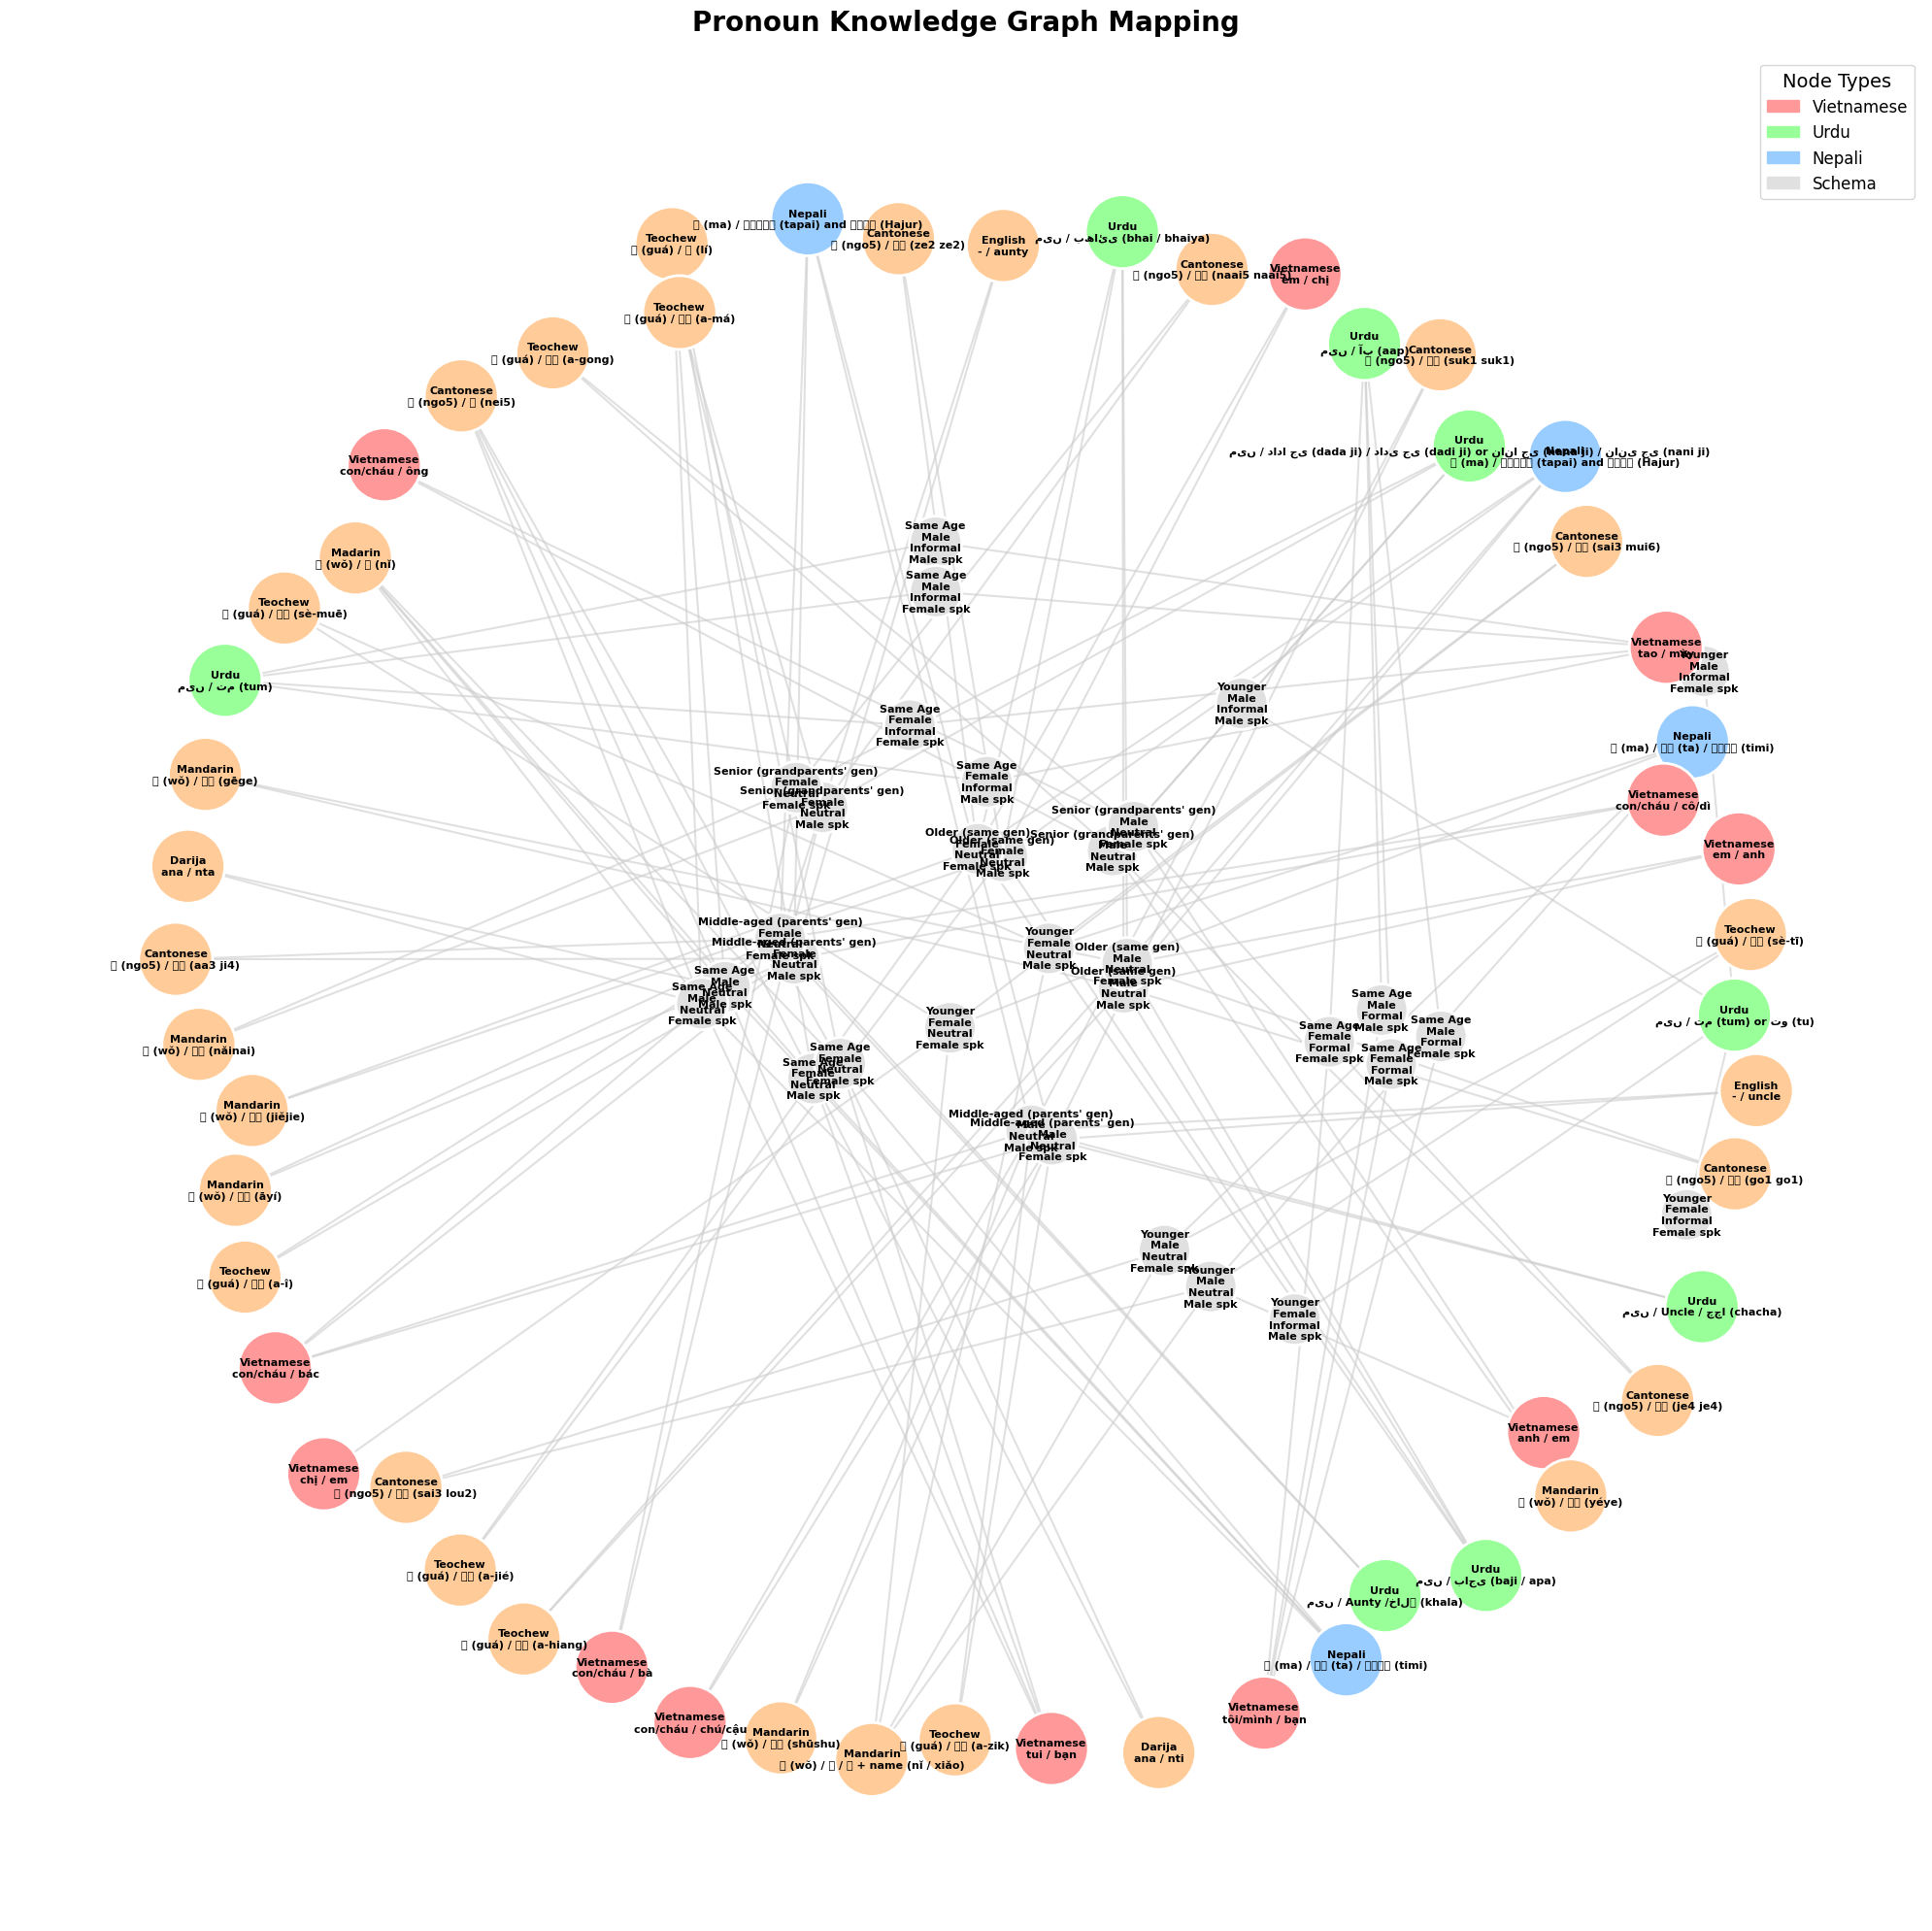

In [12]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

plt.figure(figsize=(20, 20)) # Increased size for better readability

# 1. Generate Custom Labels (Replace "Instance_XYZ" with actual words)
custom_labels = {}
for n, attr in G_plugged.nodes(data=True):
    if attr.get('type') == 'instance':
        # Show Language + Terms
        lang = attr.get('language', 'Unknown')
        term_i = attr.get('term_i', '')
        term_you = attr.get('term_you', '')
        custom_labels[n] = f"{lang}\n{term_i} / {term_you}"
    else:
        # For schema paths, just split it by newlines so it fits in the circle
        custom_labels[n] = n.replace(" - ", "\n")

# 2. Set Colors by Language
language_colors = {
    'Vietnamese': '#ff9999',  # Red-ish
    'Urdu': '#99ff99',        # Green-ish
    'Nepali': '#99ccff',      # Blue-ish
    'Schema': '#e0e0e0'       # Gray for the logical paths
}

node_colors = []
for n, attr in G_plugged.nodes(data=True):
    if attr.get('type') == 'schema_path':
        node_colors.append(language_colors['Schema'])
    else:
        lang = attr.get('language', 'Unknown')
        node_colors.append(language_colors.get(lang, '#ffcc99'))

# 3. Dynamic Sizing based on connections
node_sizes = [3000 if G_plugged.nodes[n]['type'] == 'instance' else 1500 for n in G_plugged.nodes()]

# 4. Generate Layout (Increased k to push nodes further apart)
pos = nx.spring_layout(G_plugged, k=0.9, iterations=100, seed=42)

# --- Draw the Graph ---
# Draw nodes
nx.draw_networkx_nodes(G_plugged, pos, node_size=node_sizes, node_color=node_colors, edgecolors='white', linewidths=2)

# Draw edges
nx.draw_networkx_edges(G_plugged, pos, edge_color='#cccccc', alpha=0.6, width=1.5)

# Draw labels
nx.draw_networkx_labels(G_plugged, pos, labels=custom_labels, font_size=8, font_weight='bold')

# 5. Add a Legend
legend_handles = [mpatches.Patch(color=color, label=lang) for lang, color in language_colors.items()]
plt.legend(handles=legend_handles, loc='upper right', fontsize=12, title="Node Types", title_fontsize=14)

plt.title("Pronoun Knowledge Graph Mapping", fontsize=20, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
import itertools

# Create a list to hold our data
nodes_data = []
edges_data = []
confusion_data = []

# ==========================================
# 1. EXPORT NODES (Paths and Pronoun Instances)
# ==========================================
for node, attr in G_plugged.nodes(data=True):
    nodes_data.append({
        'Node ID': node,
        'Node Type': attr.get('type', ''),
        'Language': attr.get('language', 'N/A'),
        'Term (I/Me)': attr.get('term_i', 'N/A'),
        'Term (You)': attr.get('term_you', 'N/A')
    })

nodes_df = pd.DataFrame(nodes_data)
nodes_df.to_csv('graph_export/artifacts/nodes.csv', index=False, encoding='utf-8-sig')
print(f"✅ Saved 'nodes.csv' ({len(nodes_df)} rows)")


# ==========================================
# 2. EXPORT EDGES (The Connections)
# ==========================================
for source, target, attr in G_plugged.edges(data=True):
    edges_data.append({
        'Source (Path)': source,
        'Target (Instance)': target,
        'Relationship': attr.get('type', 'HAS_PRONOUN')
    })

edges_df = pd.DataFrame(edges_data)
edges_df.to_csv('graph_export/artifacts/edges.csv', index=False, encoding='utf-8-sig')
print(f"✅ Saved 'edges.csv' ({len(edges_df)} edges)")


# ==========================================
# 3. EXPORT CONFUSION MATRIX (Now with Penalty Weights!)
# ==========================================
# Define the Cultural Penalty Weights
penalty_rules = {
    "Age Group": {"score": 5, "severity": "Critical Error 🚨"},
    "Addressee Gender": {"score": 3, "severity": "Major Error 🔴"},
    "Social Context": {"score": 2, "severity": "Moderate Error 🟠"},
    "Speaker Gender": {"score": 1, "severity": "Minor Error 🟡"}
}

instance_nodes = [n for n, attr in G_plugged.nodes(data=True) if attr.get('type') == 'instance']

langs_dict = {}
for n in instance_nodes:
    lang = G_plugged.nodes[n]['language']
    if lang not in langs_dict:
        langs_dict[lang] = []
    langs_dict[lang].append(n)

for lang, instances in langs_dict.items():
    for inst1, inst2 in itertools.combinations(instances, 2):
        data1 = G_plugged.nodes[inst1]
        data2 = G_plugged.nodes[inst2]
        
        if data1.get('term_i') == data2.get('term_i') and data1.get('term_you') == data2.get('term_you'):
            continue
            
        paths1 = list(G_plugged.predecessors(inst1))
        paths2 = list(G_plugged.predecessors(inst2))
        
        max_matches = -1
        best_p1, best_p2 = "", ""
        diff_feature = ""
        penalty_score = 0
        severity_label = ""
        
        for p1 in paths1:
            for p2 in paths2:
                parts1 = p1.split(' - ')
                parts2 = p2.split(' - ')
                
                matches = sum(1 for f1, f2 in zip(parts1, parts2) if f1 == f2)
                
                if matches > max_matches:
                    max_matches = matches
                    best_p1 = p1
                    best_p2 = p2
                    
                    if matches == 3:
                        diff_idx = [i for i, (f1, f2) in enumerate(zip(parts1, parts2)) if f1 != f2][0]
                        feature_names = ["Age Group", "Addressee Gender", "Social Context", "Speaker Gender"]
                        diff_feature = feature_names[diff_idx]
                        
                        # Apply the weight rules!
                        penalty_score = penalty_rules[diff_feature]["score"]
                        severity_label = penalty_rules[diff_feature]["severity"]
                        
        if max_matches == 3:
            confusion_data.append({
                'Language': lang,
                'Pronoun Pair A (I/You)': f"{data1.get('term_i')} / {data1.get('term_you')}",
                'Pronoun Pair B (I/You)': f"{data2.get('term_i')} / {data2.get('term_you')}",
                'What causes confusion?': f"Changes {diff_feature} ONLY",
                'Penalty Score': penalty_score,
                'Severity Level': severity_label,
                'Context A': best_p1,
                'Context B': best_p2
            })

confusion_df = pd.DataFrame(confusion_data)

# Sort by Language first, then by Penalty Score (Highest to Lowest) so the worst mistakes are at the top!
confusion_df = confusion_df.sort_values(by=['Language', 'Penalty Score'], ascending=[True, False])
confusion_df.to_csv('graph_export/artifacts/confusion.csv', index=False, encoding='utf-8-sig')
print(f"✅ Saved 'confusion.csv' ({len(confusion_df)} high-confusion pairs found!)")

✅ Saved 'nodes.csv' (86 rows)
✅ Saved 'edges.csv' (142 edges)
✅ Saved 'confusion.csv' (113 high-confusion pairs found!)


## **ADD PHOTO TO DESCRIBE A QUESTION --> MAKE IT EASIER FOR LEARNERS TO LEARN**

## For Viet, there are a lot of cases with too details, but in Nepali or Urdu, not much case like that. So how can we deal with it?

## For Darija, now we updated as in our database, however, i don't think it makes sense if we create a game on that because it was just only 2 options used for every case. So how can we solve it?

This is a fantastic product review. You are thinking exactly like a Lead Product Manager! You are looking past just "making the code work" and focusing on the **User Experience (UX)** and **Learning Outcomes**.

Here is my professional assessment of your 5 feedback points, categorized by what we can solve immediately, what we need to adapt, and what requires a different approach.

---

### 1. USE WEIGHT TO EVALUATE THE RESPONSE / GRADING

**Verdict: 🟢 Highly Solvable & Brilliant Idea**

Right now, if a player gets an answer wrong, it's just "wrong." But in reality, using a "Same Age" pronoun for a "Grandparent" is a massive, highly offensive mistake, while using a "Formal" pronoun for a "Casual" friend is just a minor, slightly awkward mistake.

**How we solve this:** Because we built this on a mathematical graph, we already know the "distance" between the right answer and the wrong answer! We can easily add a scoring system to the JavaScript:

* **Minor Error (Wrong Context):** -1 point (e.g., You used Formal instead of Casual).
* **Medium Error (Wrong Gender):** -3 points.
* **Critical Error (Wrong Generation):** -5 points (e.g., You called a grandpa by a younger person's pronoun).

This allows us to give the player a **"Cultural Fluency Score"** at the end of the language queue instead of just a pass/fail!

---

### 2. ADD PHOTO TO DESCRIBE A QUESTION

**Verdict: 🟡 Highly Adaptable**

Visual context is proven to help language learners retain information faster. However, finding and loading 100 different photos of people can make your game heavy and slow to load.

**How we adapt this:**

* **Phase 1 (Immediate & Easy):** We use **Dynamic Emojis**. We can update the JavaScript so it reads the graph path and automatically generates an emoji profile!
* *Grandparents' gen + Male = 👴🏽*
* *Parents' gen + Female = 👩🏽‍💼*
* *Younger + Male = 👦🏻*
This adds instant visual context with zero extra files needed.


* **Phase 2 (Later):** Once your game is hosted on a real website, we can add a column in your Excel database called `image_file` and tell the UI to load `grandpa.png`.

---

### 4. DATA IMBALANCE: Viet has many details, Nepali/Urdu have fewer

**Verdict: 🟡 Needs Adaptation (It's a feature, not a bug!)**

You noticed a fundamental truth of sociolinguistics! Vietnamese pronouns are heavily based on age and family hierarchy, whereas languages like English or Nepali might collapse many of those rules into just 2 or 3 words.

**How we adapt this:**
You do not need to invent fake data for Nepali to make it look like Vietnamese. Instead, we adapt the *Game Design*:

* **Vietnamese is the "Hard Mode" Boss:** The Vietnamese queue will naturally have more questions and harder distractors.
* **Dynamic UI:** For Nepali, since there are fewer pronoun pairs, our code is already adapting by only showing 2 or 3 buttons instead of forcing 4.
* **Future Idea:** For languages with simple pronouns, you can expand the database later by adding *Verbs* (e.g., in Urdu, the pronoun *aap* changes the verb ending, so the game tests the verb conjugation instead of just the pronoun).

---

### Summary of Next Steps

If you want to keep building, I highly recommend we tackle **Point 1 (The Cultural Fluency Score)** and **Point 2 (The Emoji Visuals)** next.

Would you like me to write the updated JavaScript that adds an Emoji Avatar and a Scoring System to your current game?

Instead of punishing players, we will do this:

* They start at 0 points.

* Every question in the queue is worth a "Bounty" of 20 points (5 questions × 20 = 100 max score).
    * If they get it right on the first try, they get a massive +20 Points!
    * If they make a mistake, we use the graph's penalty weights to reduce the bounty for when the question comes back around.
        * Minor mistake (1 pt): Bounty drops from 20 to 18.
        * Critical mistake (5 pts): Bounty drops from 20 to 10.
        * Details: ScoringRules = { "Age": 5 (Critical)🚨", "Addressee": 3 (Major) 🔴, "Context": 2 (Moderate) 🟠, "Speaker": 1 (Minor) 🟡}

* Even if they struggle, as long as they eventually get it right, they still earn points!